## LLM exploration trajectory

3D trajectory: X = iteration, Y = `coupon_to_bath_wait_time`, Z = target property. Color defaults to fit
quality (`Good Fit`), same green/orange/red convention as `EVALUATE/fit_evaluation_log.html` -- pass
`color_col="<any numeric column>"` to color by a parameter instead (continuous colorbar, e.g.
`color_col="mixing_temp"` or even `color_col=z_col` for an extra depth cue).

Data source: `tests/csv_tests/test_reps.csv` -- a full pipeline reprocess (regenerated 2026-07-13) covering
**34 conditions**, not just the 20 in `data/results/results_reps.csv`. The 14 "missing" ones (17-13deg-*,
10-25degMix-*, and the earliest 17-5deg-4s/7s/9s runs from June 1-9) predate `run_loop.py`'s active-learning
loop -- manual/scripted sweeps, not LLM decisions -- but they're real measured data and 13 of the 14 have
usable values. That file's `date` column is just the regen batch timestamp, so real experiment dates are
recovered from the raw specimen filenames (`Specimen_N_MMDDYYYY_HHMMSS.csv`) in `data/raw/<condition>/`.

`REAL_CAMPAIGN_ONLY` restricts to the actual LLM active-learning campaign only (`nips_bath_wait_time >=
MIN_NIPS_WAIT`, i.e. after run_loop.py existed) if you want to exclude the pre-automation data -- off by
default here to show the full lifetime.

`per_rep=True` plots each of the 3 reps individually -- use this for a per-specimen property like Strain
at 50 bar. `per_rep=False` plots one point per condition -- use this for CV, which is a condition-level
stat (identical across its 3 reps), so per-rep dots would just overlap.

In [1]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = Path("..") / "data" / "results" / "results_agg_llm.csv"
REPS_FULL_PATH = Path("..") / "tests" / "csv_tests" / "test_reps.csv"
RAW_ROOT = Path("..") / "data" / "raw"

# conditions to drop from the trajectory entirely -- not representative of a real
# active-learning step under the correct objective
EXCLUDE_CONDITIONS = {
    "10-25degMix-25deg-0s-NoN2-1800s",  # wrong prompt: told the LLM to MAXIMIZE Strain at 50 bar
}

df = pd.read_csv(CSV_PATH)
df["_dt"] = pd.to_datetime(df["date"].str.replace("\n", " "))
df = df.sort_values("_dt").reset_index(drop=True)
df["iteration"] = range(1, len(df) + 1)

SPECIMEN_RE = re.compile(r"(\d{8})_(\d{6})")

def true_condition_date(cond):
    """Earliest specimen timestamp for a condition, read from its raw folder
    (test_reps.csv's own date column is just a regen batch timestamp)."""
    d = RAW_ROOT / cond
    if not d.is_dir():
        return pd.NaT
    stamps = []
    for f in d.glob("Specimen_*.csv"):
        m = SPECIMEN_RE.search(f.name)
        if m:
            stamps.append(pd.to_datetime(m.group(1) + m.group(2), format="%m%d%Y%H%M%S"))
    return min(stamps) if stamps else pd.NaT

reps_df = pd.read_csv(REPS_FULL_PATH)
reps_df["condition"] = reps_df["name"].str.split(r"\s*\|\s*rep").str[0]
reps_df = reps_df[~reps_df["condition"].isin(EXCLUDE_CONDITIONS)].reset_index(drop=True)
reps_df["_dt"] = reps_df["condition"].apply(true_condition_date)
reps_df = reps_df.sort_values("_dt").reset_index(drop=True)
print(f"{len(reps_df)} rep rows loaded across {reps_df['condition'].nunique()} conditions "
      f"({reps_df['_dt'].min().date()} to {reps_df['_dt'].max().date()}), "
      f"{len(EXCLUDE_CONDITIONS)} condition(s) excluded")

103 rep rows loaded across 34 conditions (2026-05-28 to 2026-08-10), 1 condition(s) excluded


In [2]:
# reference: numeric columns available for X / Y
df.select_dtypes("number").columns.tolist()

['mixing_temp',
 'bath_temp',
 'polymer_wt',
 'additive_wt',
 'pullcast_speed',
 'coupon_to_bath_wait_time',
 'nips_bath_wait_time',
 'initial_report',
 'Air Temp Mean',
 'Humidity Mean',
 'Thickness Mean',
 'Thickness SD',
 'Elastic Modulus Mean',
 'Elastic Modulus SD',
 'Yield Strength Mean',
 'Yield Strength SD',
 'Pore Fraction Mean',
 'Pore Fraction SD',
 'Slope Plateau Mean',
 'Slope Plateau SD',
 'Slope Densification Mean',
 'Slope Densification SD',
 'Creep Strain Mean',
 'Creep Strain SD',
 'Strain at 50 bar Mean',
 'Strain at 50 bar SD',
 'Strain at 80 bar Mean',
 'Strain at 80 bar SD',
 'Strain at 150 bar Mean',
 'Strain at 150 bar SD',
 'Strain at 500 bar Mean',
 'Strain at 500 bar SD',
 'CV Mean',
 'final_report',
 'iteration']

In [3]:
MIN_NIPS_WAIT = 1000  # set REAL_CAMPAIGN_ONLY=True in a call to restrict to the post-run_loop LLM campaign

order = reps_df.drop_duplicates("condition").sort_values("_dt")["condition"].tolist()
condition_iteration = {c: i + 1 for i, c in enumerate(order)}
reps_df["iteration"] = reps_df["condition"].map(condition_iteration)

saved: ../data/plots/poster/trajectory_elastic_strain.png


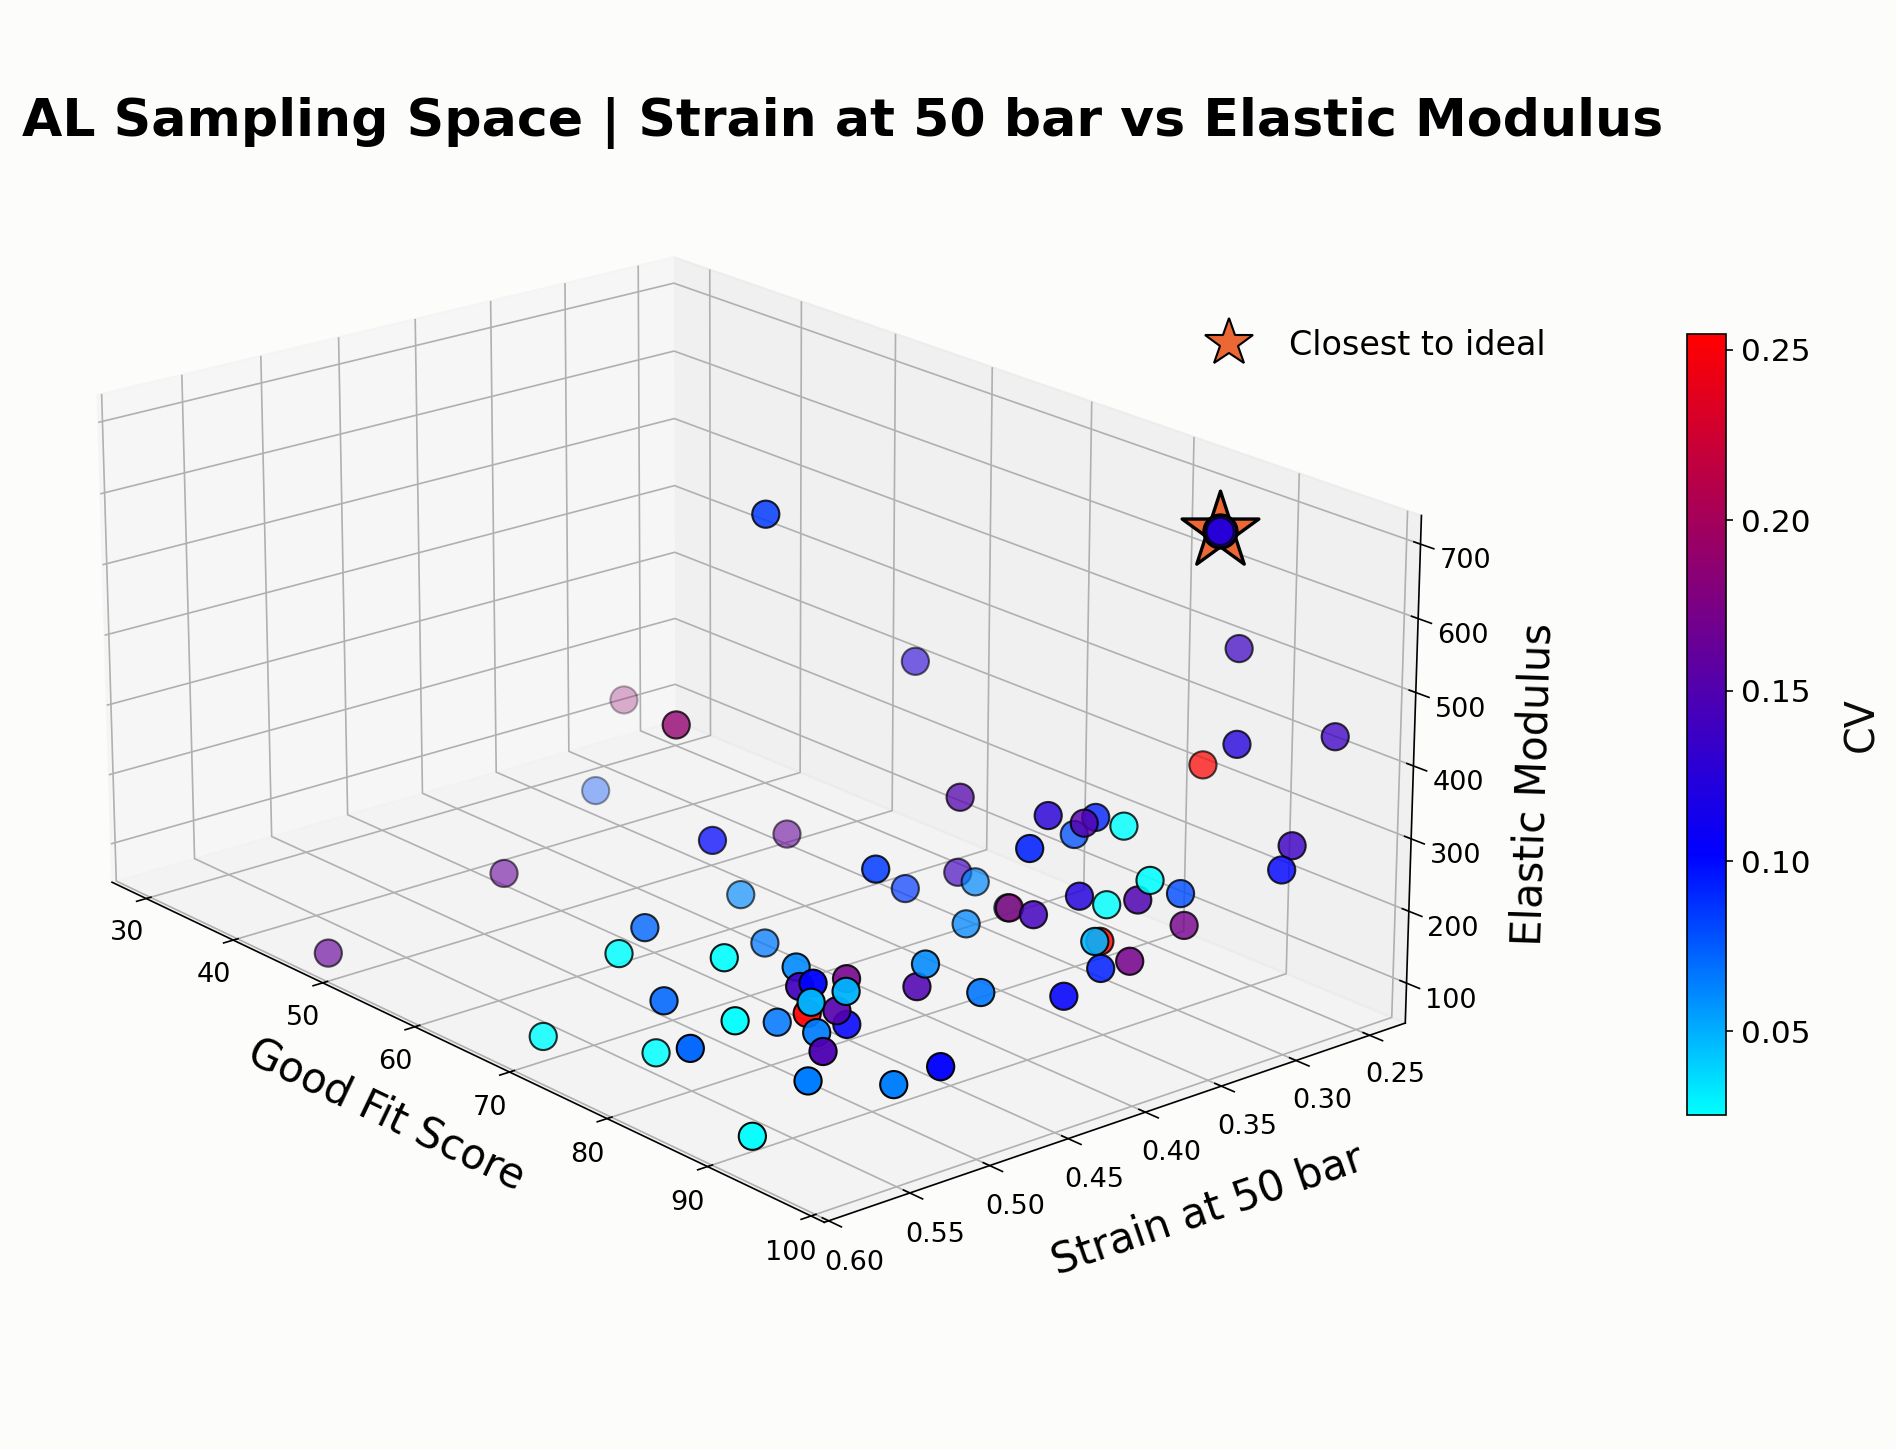

date                                                       2026-07-13\n16:28:05
name                                              17-5deg-400s-N2-1807s | rep 1
Trial                                                                  sample 5
Thickness                                                              143.7894
Elastic Modulus                                                      652.454418
Yield Strength                                                        17.825087
Changepoint                                                            0.355141
Slope Plateau                                                        146.823187
Slope Densification                                                  294.978307
Creep Strain                                                           0.061135
Strain at 50 bar                                                       0.249231
Strain at 80 bar                                                       0.396389
Strain at 150 bar                       

In [84]:
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
MAROON_BLUE = LinearSegmentedColormap.from_list("maroon_blue", ["cyan", "blue", "purple", "red"])
GREY_WASH = LinearSegmentedColormap.from_list("grey_wash", ["#fcfcfb", "#c9c8c1"])
BEST_COLOR = "#eb6834"
INK = "#0b0b0b"

def _tight_limits(lo, hi, pad_frac=0.04):
    pad = (hi - lo) * pad_frac or abs(hi) * pad_frac or 1
    return lo, hi + pad

def plot_3d_trajectory(reps_df, y_col, z_col, x_col="iteration", color_col="Good Fit Score",
                        y_higher_is_better=True, z_higher_is_better=False, per_rep=True,
                        figsize=(22, 11), box_aspect=(1.5, 1.0, 0.7), dpi=150, out_path=None):
    d = reps_df.dropna(subset=[y_col, z_col]).copy()
    means = d.groupby("condition").agg({x_col: "first", y_col: "first", z_col: "mean"}).sort_values(x_col)

    good = d[d["Good Fit"].astype(bool)]
    y_lo0, y_hi0 = d[y_col].min(), d[y_col].max()
    z_lo0, z_hi0 = d[z_col].min(), d[z_col].max()
    yn = (good[y_col] - y_lo0) / (y_hi0 - y_lo0 + 1e-12)
    zn = (good[z_col] - z_lo0) / (z_hi0 - z_lo0 + 1e-12)
    y_ideal = yn if y_higher_is_better else (1 - yn)
    z_ideal = zn if z_higher_is_better else (1 - zn)
    dist = np.sqrt((1 - y_ideal) ** 2 + (1 - z_ideal) ** 2)
    best_idx = dist.idxmin()
    best = d.loc[best_idx]

    fig = plt.figure(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("#fcfcfb")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("#fcfcfb")
    ax.set_box_aspect(box_aspect)

    x_lo, x_hi = _tight_limits(d[x_col].min(), d[x_col].max(), 0.06)
    y_lo, y_hi = _tight_limits(y_lo0, y_hi0)
    z_lo, z_hi = _tight_limits(z_lo0, z_hi0)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    ax.set_zlim(z_lo, z_hi)

    # ax.plot(means[x_col], means[y_col], means[z_col], "-", color="gray", alpha=0.5, zorder=1, linewidth=1.4)
    sc = ax.scatter(d[x_col], d[y_col], d[z_col],
                     c=d[color_col], cmap=MAROON_BLUE,
                     # color="#2a78d6",
                     edgecolor="k", s=170, zorder=2, depthshade=True)
    ax.scatter([best[x_col]], [best[y_col]], [best[z_col]], marker="*", s=1500, c=BEST_COLOR,
               edgecolor="k", linewidth=1.6, zorder=9, depthshade=False)
    ax.scatter([best[x_col]], [best[y_col]], [best[z_col]], c=[best[color_col]], cmap=MAROON_BLUE,
               vmin=d[color_col].min(), vmax=d[color_col].max(),
               s=250, edgecolor="k", linewidth=1.6, zorder=10, depthshade=False)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.08)
    cbar.set_label(color_col, fontsize=19, color=INK, labelpad=15)
    cbar.ax.tick_params(labelsize=15)

    legend_items = [Line2D([0], [0], marker="*", color="none", markerfacecolor=BEST_COLOR,
                            markeredgecolor="k", markersize=24, label="Closest to ideal")]
    ax.legend(handles=legend_items, loc="upper right", fontsize=16, frameon=False, bbox_to_anchor=(1.1, 0.8))

    ax.set_xlabel(x_col, labelpad=16, fontsize=20)
    ax.set_ylabel(y_col, labelpad=16, fontsize=20)
    ax.set_zlabel(z_col, labelpad=10, fontsize=20)
    ax.xaxis.set_tick_params(labelsize=13)
    ax.yaxis.set_tick_params(labelsize=13)
    ax.zaxis.set_tick_params(labelsize=13)
    fig.suptitle(f"AL Sampling Space | {y_col} vs {z_col}", fontsize=25, fontweight="bold", y=0.85, x=0.58)

    ax.invert_yaxis()
    ax.view_init(elev=20, azim=-40)
    fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.04)

    if out_path:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, dpi=300, facecolor="#fcfcfb")
        print(f"saved: {out_path}")
    plt.show()
    return best
# edit and rerun -- per-specimen property, so per_rep=True
plot_3d_trajectory(reps_df, y_col="Strain at 50 bar", z_col="Elastic Modulus", x_col="Good Fit Score", color_col="CV",
                    y_higher_is_better=False, z_higher_is_better=True, per_rep = False,
                    out_path=Path("..") / "data" / "plots" / "poster" / "trajectory_elastic_strain.png")
# plot_3d_trajectory(reps_df, y_col="Elastic Modulus", z_col="Strain at 50 bar", x_col="Good Fit Score", color_col="CV",
#                     y_higher_is_better=True, z_higher_is_better=False,
#                     out_path=Path("..") / "data" / "plots" / "poster" / "trajectory_elastic_strain.png")

saved: ../data/plots/poster/trajectory_elastic_strain.png


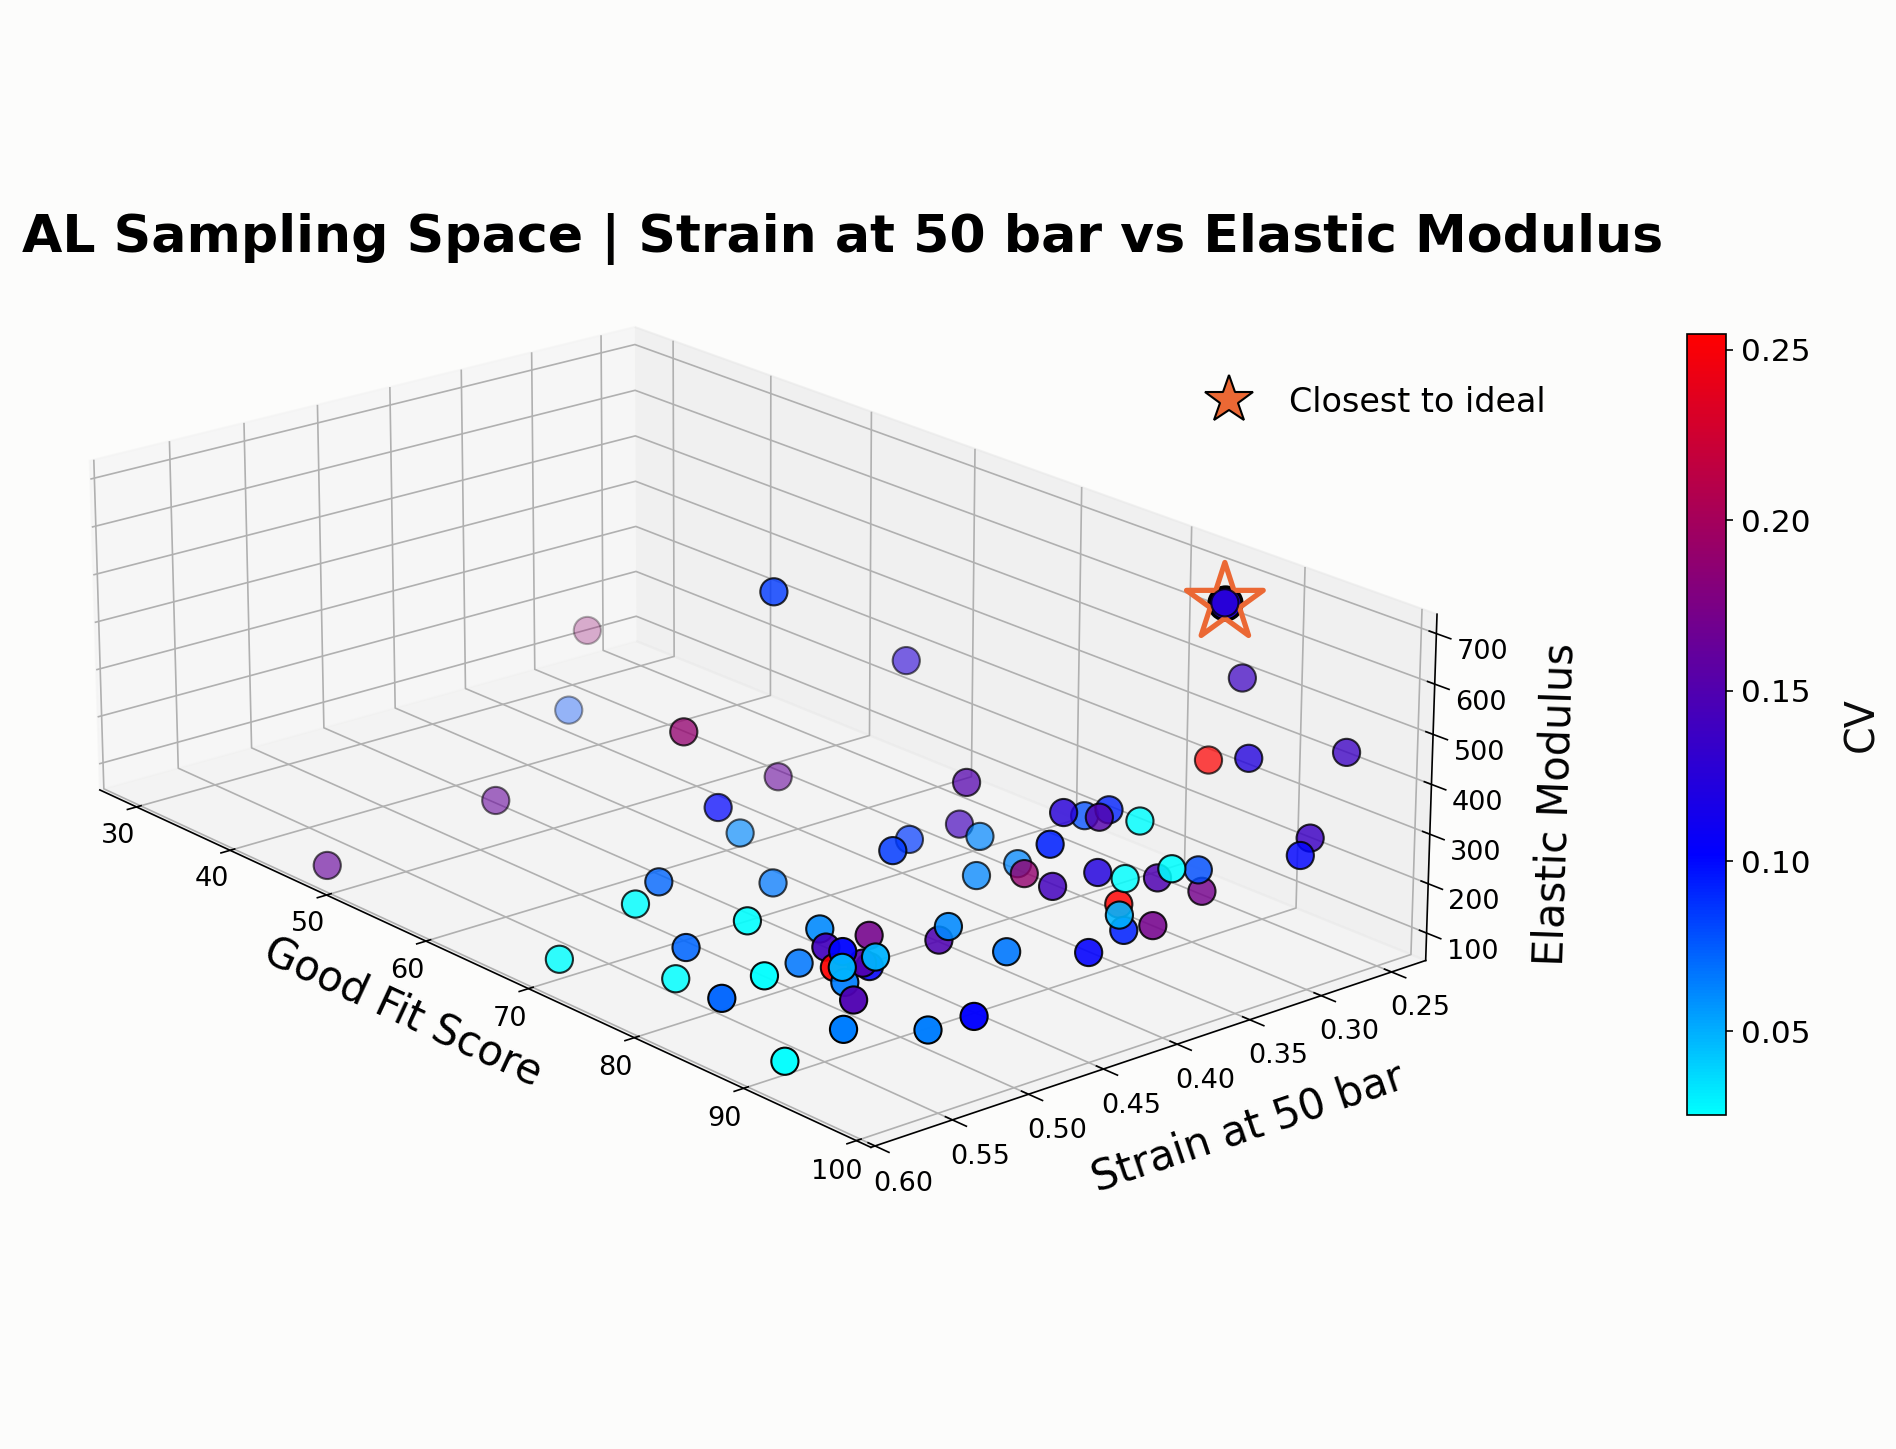

date                                                       2026-07-13\n16:28:05
name                                              17-5deg-400s-N2-1807s | rep 1
Trial                                                                  sample 5
Thickness                                                              143.7894
Elastic Modulus                                                      652.454418
Yield Strength                                                        17.825087
Changepoint                                                            0.355141
Slope Plateau                                                        146.823187
Slope Densification                                                  294.978307
Creep Strain                                                           0.061135
Strain at 50 bar                                                       0.249231
Strain at 80 bar                                                       0.396389
Strain at 150 bar                       

In [65]:
# edit and rerun -- per-specimen property, so per_rep=True
plot_3d_trajectory(reps_df, y_col="Strain at 50 bar", z_col="Elastic Modulus", x_col="Good Fit Score", color_col="CV",
                    y_higher_is_better=False, z_higher_is_better=True,
                    out_path=Path("..") / "data" / "plots" / "poster" / "trajectory_elastic_strain.png")

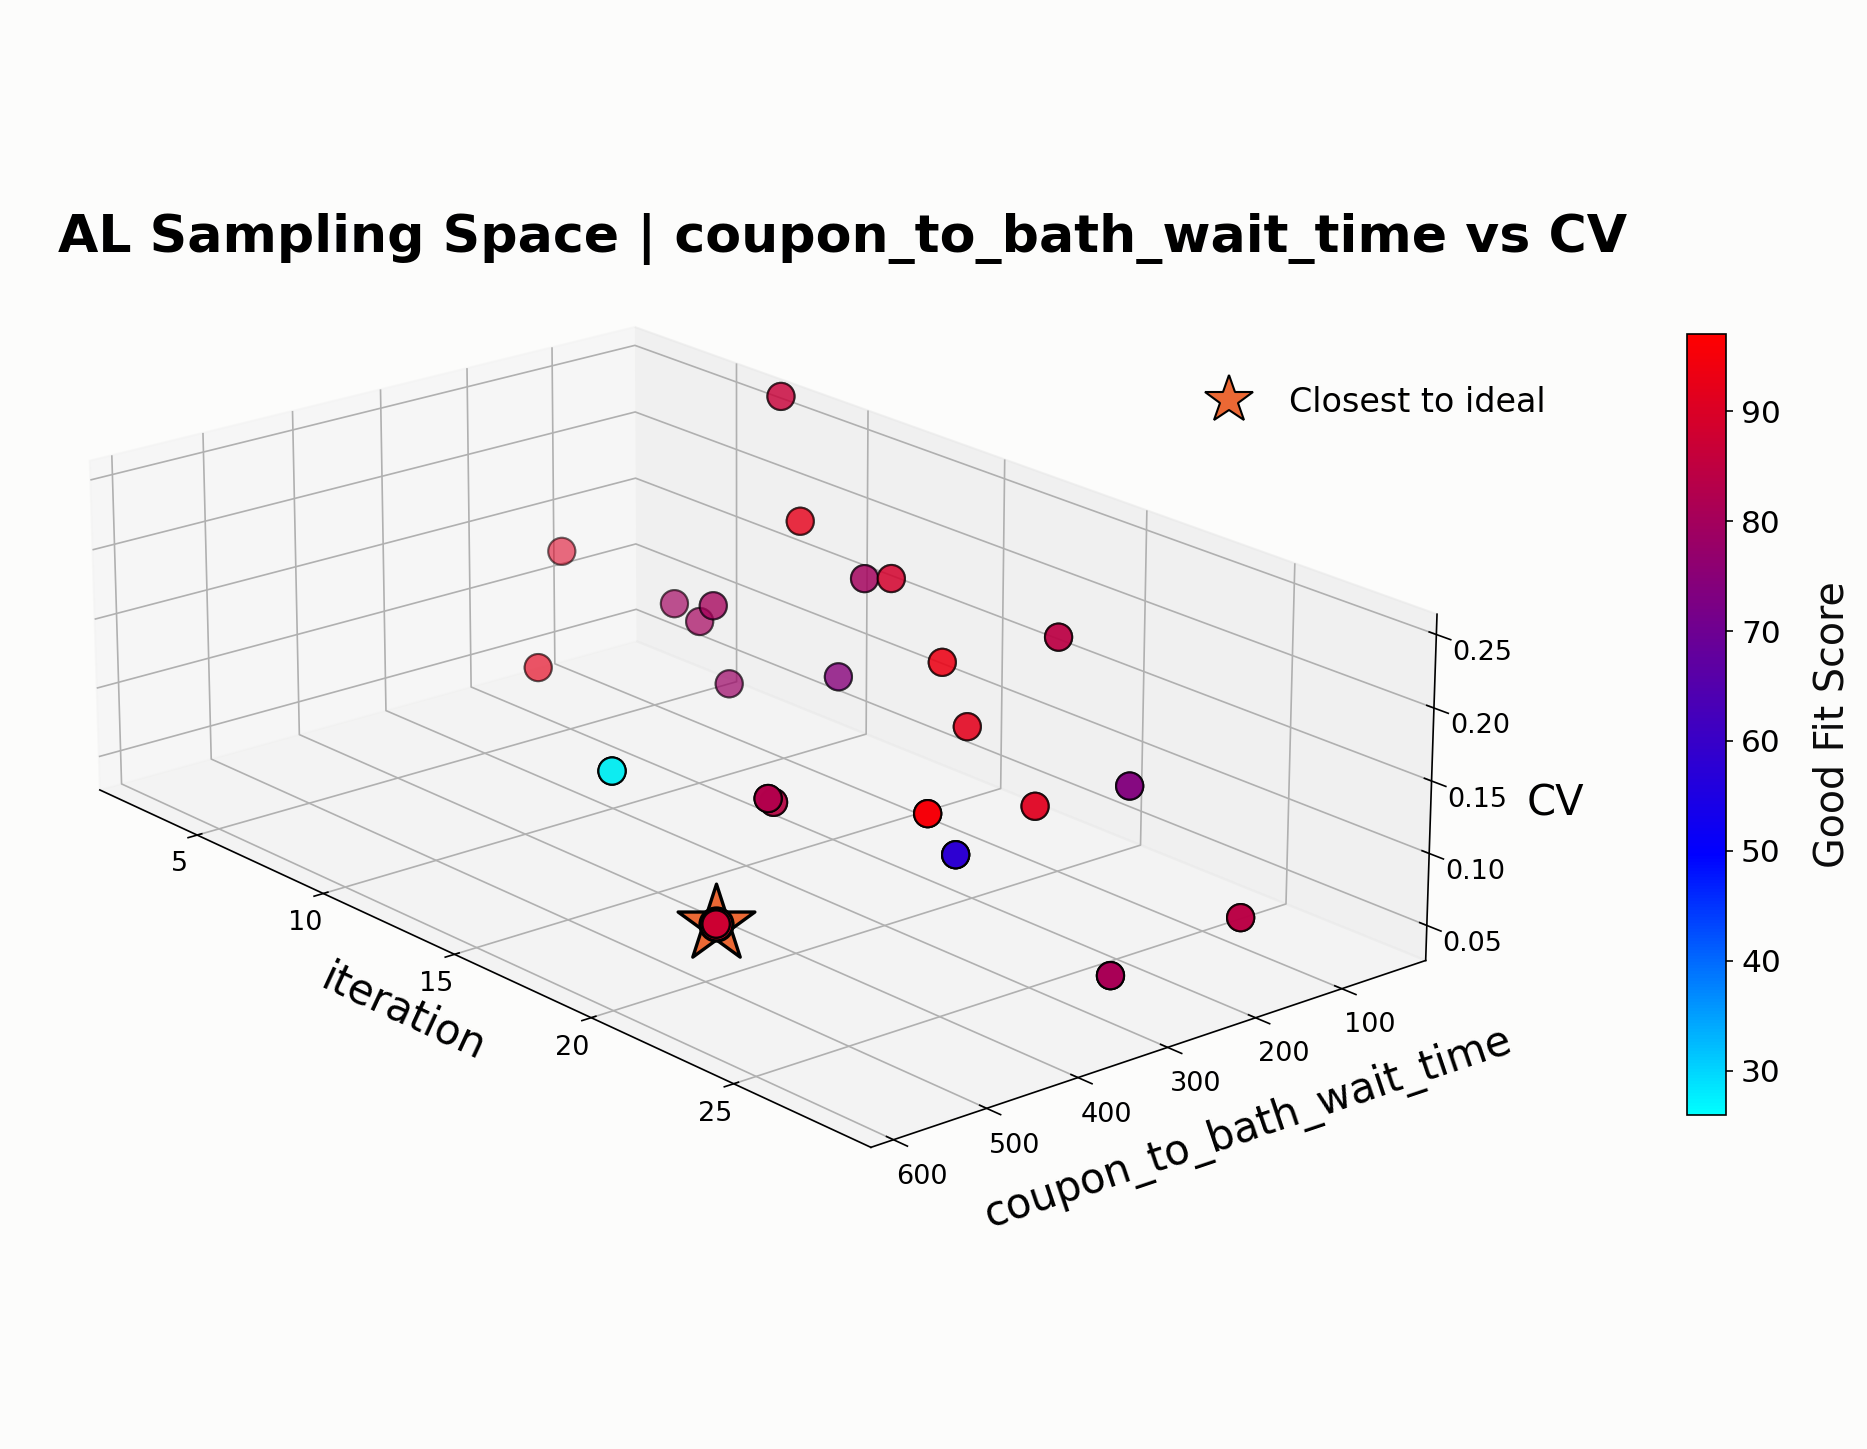

date                                                       2026-07-13\n16:28:09
name                                              17-5deg-550s-N2-1800s | rep 3
Trial                                                                 sample 12
Thickness                                                              147.6248
Elastic Modulus                                                      334.805319
Yield Strength                                                        23.073442
Changepoint                                                            0.556276
Slope Plateau                                                         80.309868
Slope Densification                                                  869.132543
Creep Strain                                                           0.053195
Strain at 50 bar                                                        0.40026
Strain at 80 bar                                                       0.565205
Strain at 150 bar                       

In [6]:
# CV is a condition-level stat (same value for all 3 reps), so per_rep=False
plot_3d_trajectory(reps_df, y_col="coupon_to_bath_wait_time", z_col="CV", per_rep=True)

## Poster figure: objective-space sampling

For a poster panel showing the LLM loop *explores*, not that it *found the optimal membrane*.
2D, not 3D -- the 3D trajectory plots above read fine on a screen but the axis labels/legend
collapse to nothing once shrunk onto a poster column, which defeats the point of a figure no one
can read.

x/y are the two objectives the LLM was actually told to optimize (see
`system_prompt.ACTIVE_LEARNING_PROMPT_TEMPLATE`: maximize Elastic Modulus, secondarily minimize
Strain at 50 bar). Color is CV (consistency across replicates) -- a third axis the prompt tells
the LLM to weigh, without cluttering the plot with a 3rd spatial dimension. One point per
condition (a composition the agent chose), not per rep. "Best" is starred using the same
priority the LLM was given -- highest modulus, and only among conditions where every rep hit
Good Fit (a claim of "best" shouldn't rest on a partially-failed fit).

Saved to `data/plots/poster/objective_space.png` at 300 DPI (~14 x 12 in at native size --
resize freely, text stays legible at typical poster-panel scale).

saved: ../data/plots/poster/objective_space.png


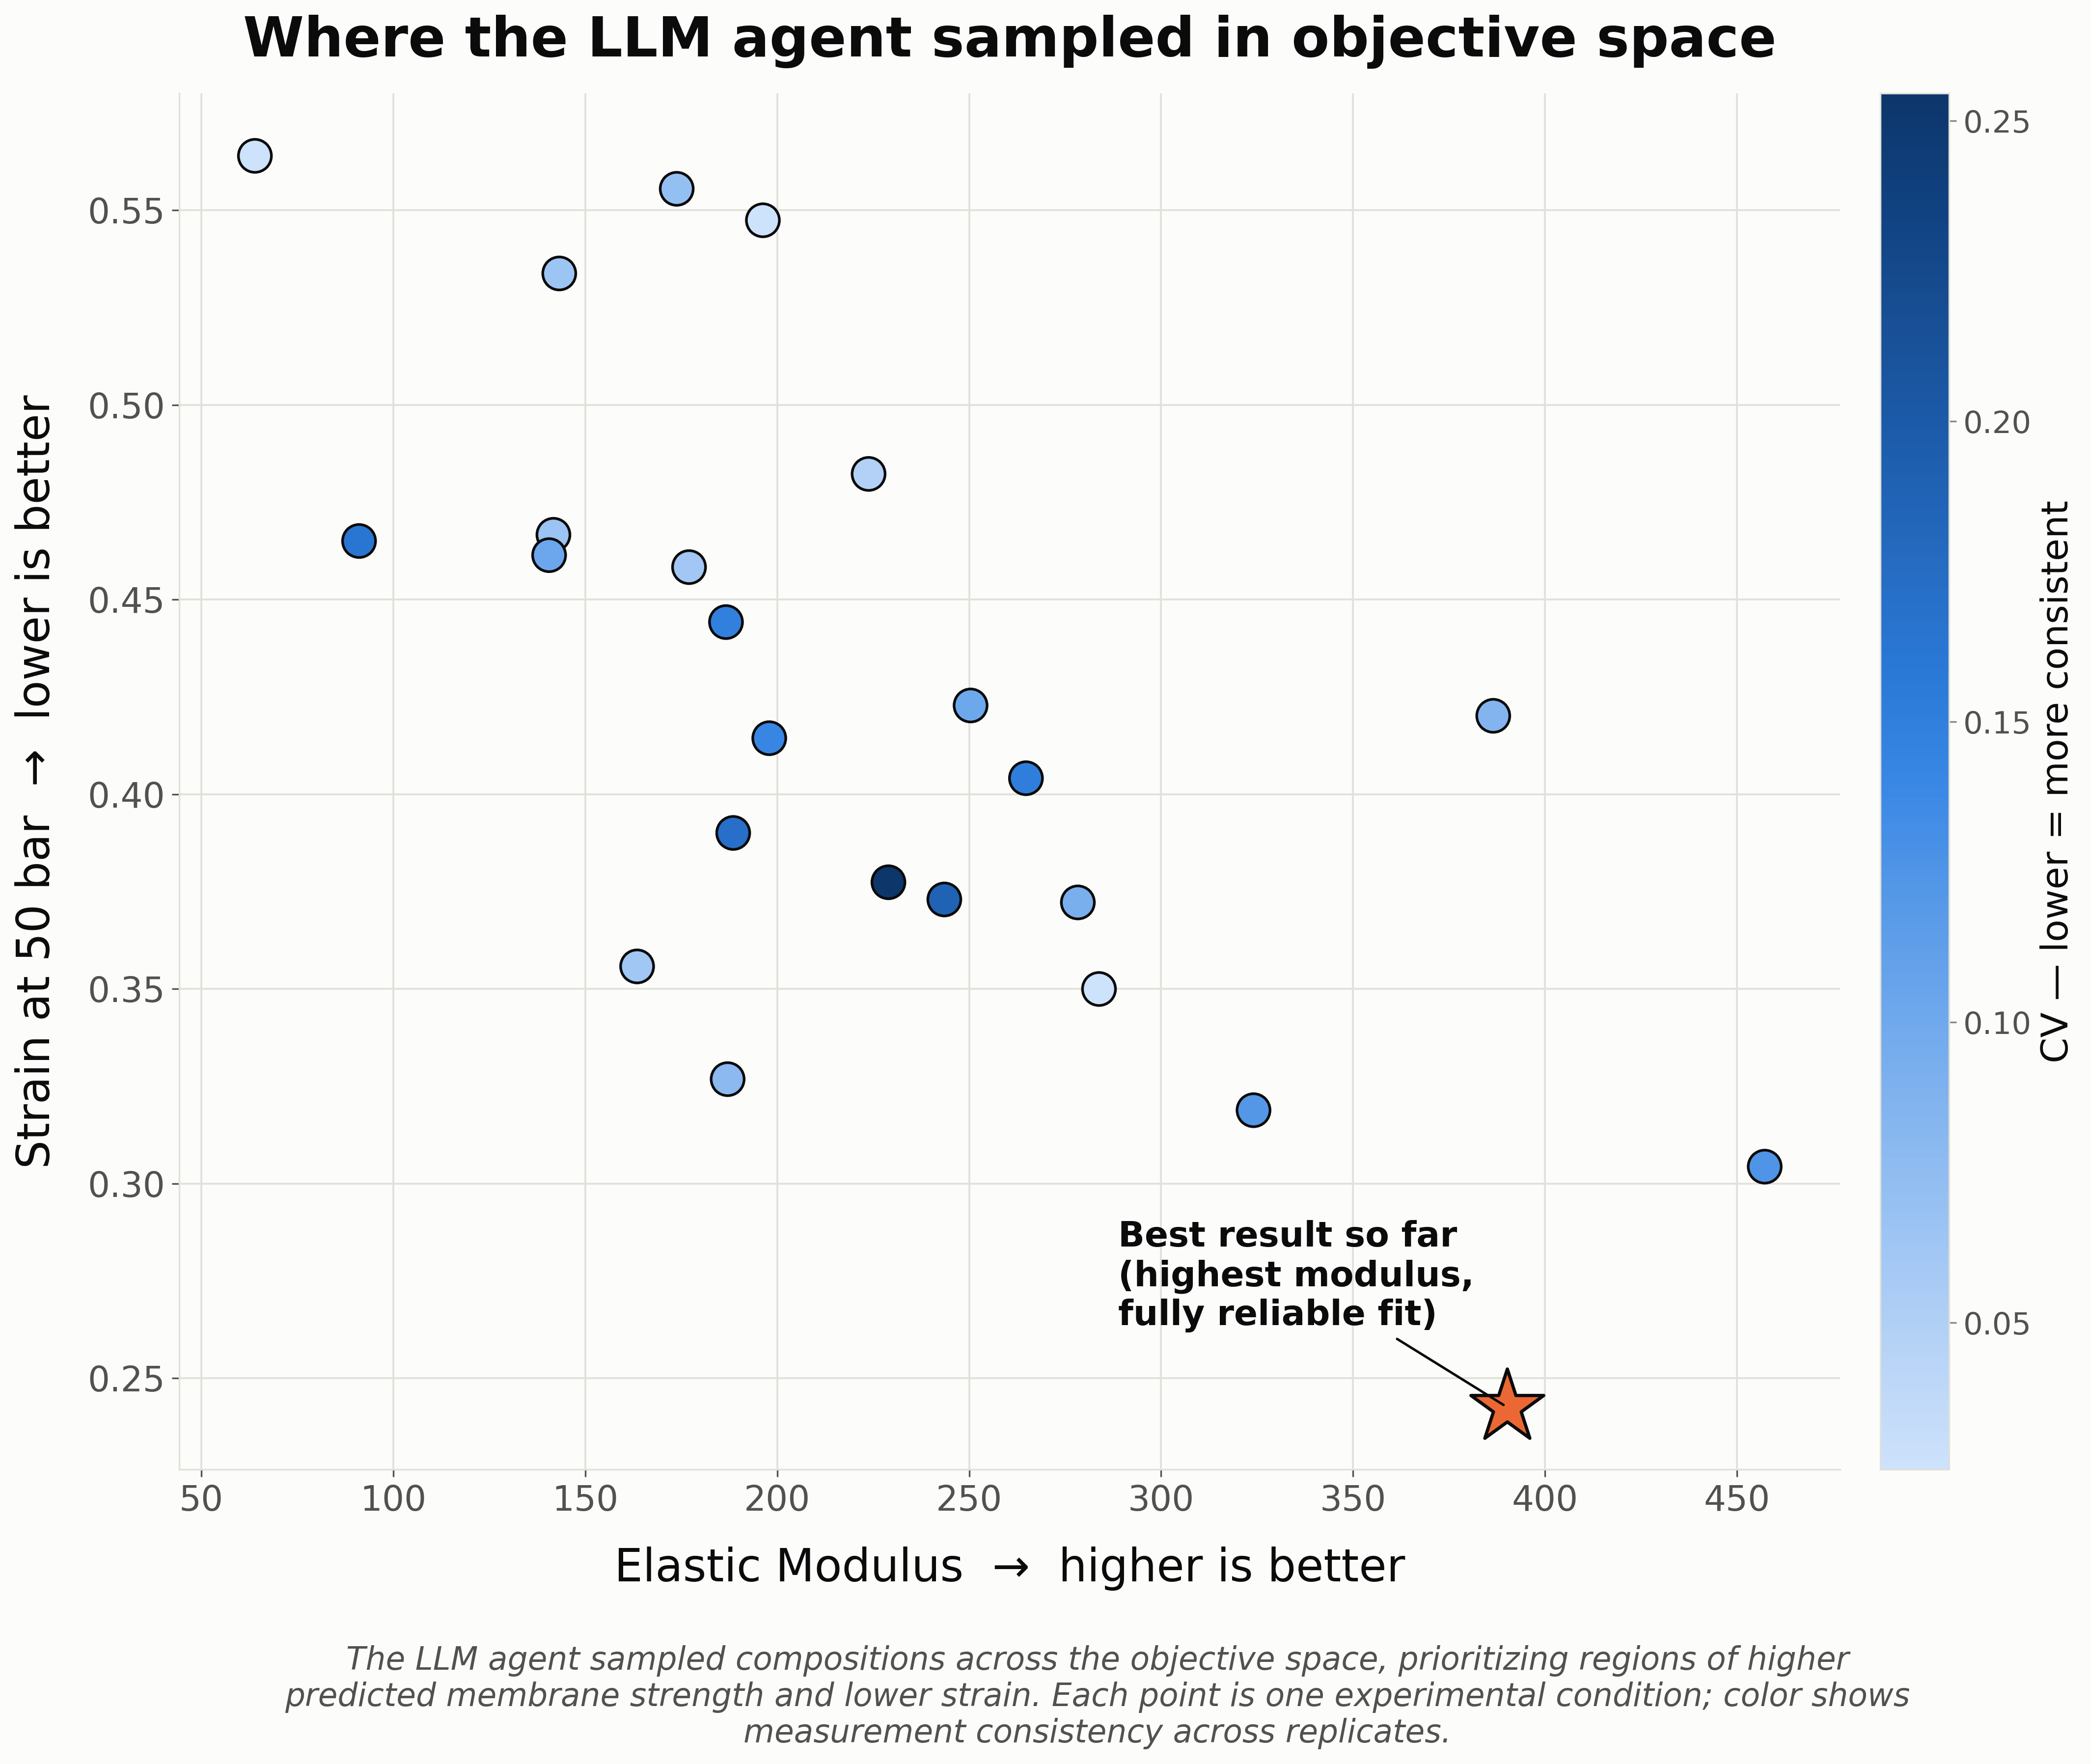

n conditions plotted: 24 | best: 17-5deg-350s-N2-1800s -> Elastic Modulus=390.1, Strain at 50 bar=0.243, CV=0.138

CAPTION (copy into poster):
The LLM agent sampled compositions across the objective space, prioritizing regions of higher predicted membrane strength and lower strain. Each point is one experimental condition; color shows measurement consistency across replicates.


In [7]:
import textwrap
from matplotlib.colors import LinearSegmentedColormap

# validated sequential blue ramp -- references/palette.md, used verbatim
SEQ_BLUE_STEPS = [
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
    "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b",
]
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE_STEPS)
BEST_COLOR = "#eb6834"  # categorical slot 2 (orange) -- validated distinct from the blue ramp
INK, SECONDARY_INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

POSTER_OUT_PATH = Path("..") / "data" / "plots" / "poster" / "objective_space.png"

def plot_objective_space(reps_df, x_col="Elastic Modulus", y_col="Strain at 50 bar", color_col="CV",
                          title="Where the LLM agent sampled in objective space",
                          x_better="higher is better", y_better="lower is better",
                          caption=None, out_path=POSTER_OUT_PATH, figsize=(15, 11)):
    """Poster-scale 2D objective-space scatter: one point per condition, colored by color_col,
    best point (by x_col, restricted to conditions where every rep hit Good Fit) starred."""
    agg = reps_df.groupby("condition").agg(**{
        x_col: (x_col, "mean"), y_col: (y_col, "mean"), color_col: (color_col, "mean"),
        "Good Fit frac": ("Good Fit", "mean"),
    }).dropna(subset=[x_col, y_col, color_col])

    reliable = agg[agg["Good Fit frac"] == 1.0]
    if reliable.empty:
        raise ValueError("no condition has every rep at Good Fit -- can't pick a trustworthy best point")
    best_name = reliable[x_col].idxmax()
    best = agg.loc[best_name]
    rest = agg.drop(index=best_name)

    plt.rcParams["font.family"] = "sans-serif"
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    sc = ax.scatter(rest[x_col], rest[y_col], c=rest[color_col], cmap=SEQ_BLUE, s=260,
                     edgecolor=INK, linewidth=1.3, zorder=2,
                     vmin=agg[color_col].min(), vmax=agg[color_col].max())
    ax.scatter([best[x_col]], [best[y_col]], marker="*", s=1400, c=BEST_COLOR,
               edgecolor=INK, linewidth=1.6, zorder=3)
    ax.annotate("Best result so far\n(highest modulus,\nfully reliable fit)",
                xy=(best[x_col], best[y_col]), xytext=(-190, 40), textcoords="offset points",
                fontsize=17, color=INK, fontweight="bold", ha="left",
                arrowprops=dict(arrowstyle="-", color=INK, lw=1.2))

    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(f"{color_col} \u2014 lower = more consistent", fontsize=18, color=INK)
    cbar.ax.tick_params(labelsize=15, color=MUTED, labelcolor=SECONDARY_INK)
    cbar.outline.set_edgecolor(GRID)

    ax.set_xlabel(f"{x_col}  \u2192  {x_better}", fontsize=22, color=INK, labelpad=14)
    ax.set_ylabel(f"{y_col}  \u2192  {y_better}", fontsize=22, color=INK, labelpad=14)
    ax.set_title(title, fontsize=27, color=INK, pad=18, fontweight="bold")
    ax.tick_params(axis="both", labelsize=17, colors=SECONDARY_INK)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(GRID)
    ax.grid(True, color=GRID, linewidth=0.9, zorder=0)

    if caption:
        fig.text(0.5, -0.02, "\n".join(textwrap.wrap(caption, 100)),
                  ha="center", va="top", fontsize=15.5, color=SECONDARY_INK, style="italic")

    fig.tight_layout()
    if out_path:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor=SURFACE)
        print(f"saved: {out_path}")
    plt.show()
    print(f"n conditions plotted: {len(agg)} | best: {best_name} -> "
          f"{x_col}={best[x_col]:.1f}, {y_col}={best[y_col]:.3f}, {color_col}={best[color_col]:.3f}")
    return agg


caption = ("The LLM agent sampled compositions across the objective space, prioritizing regions of "
           "higher predicted membrane strength and lower strain. Each point is one experimental "
           "condition; color shows measurement consistency across replicates.")
plot_objective_space(reps_df, caption=caption)
print()
print("CAPTION (copy into poster):")
print(caption)